# Automobile Fuel Efficiency Analysis — SOLUTIONS
### Modernized Python/Pandas rewrite of *Packt — Practical Data Science Cookbook, 2nd Ed., Chapter 6*

This notebook is the **fully worked solution** to the extended lab. It follows the same investigative
arc as the book chapter (EPA `vehicles.csv` fuel-economy dataset) but is updated for modern library
versions:

- The book's `ggplot` (a since-abandoned R-clone library) is replaced with **matplotlib** and **seaborn**.
- Deprecated pandas syntax (`grouped['a', 'b', 'c']`, Python-2 `print` statements) is replaced with
  current, non-deprecated equivalents.
- The dataset itself has grown since the book was written (it now runs through model year ~2027 and
  includes an `Electricity`/`Hydrogen` fuel type not present in 2017), so a few numbers will differ
  slightly from the printed book output — that's expected and is itself a good lesson in why you should
  always re-derive numbers from the data in front of you rather than trusting a cached memory of a result.

**How to use this notebook:** read a section, look at the corresponding TODO cell in
`01_skeleton_lab.ipynb`, try it yourself, *then* compare with the answer here.


## Part 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.max_columns", 100)


## Part 1 — Load the data and take inventory

Recipe reference: *Preparing to analyze automobile fuel efficiencies* / *Exploring and describing fuel
efficiency data with Python*.

The original book warns that several columns come in with **mixed dtypes** (pandas raises a
`DtypeWarning`). We pass `low_memory=False` so pandas scans the whole file before guessing a dtype per
column, which avoids the warning outright and is the modern best practice for CSVs like this one.

In [2]:
vehicles = pd.read_csv("vehicles.csv", low_memory=False)
vehicles.shape


(50242, 84)

In [3]:
len(vehicles)           # number of observations (rows)


50242

In [4]:
len(vehicles.columns)   # number of variables (columns)


84

In [5]:
print(vehicles.columns.tolist())


['barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08', 'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2', 'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U', 'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders', 'displ', 'drive', 'engId', 'eng_dscr', 'feScore', 'fuelCost08', 'fuelCostA08', 'fuelType', 'fuelType1', 'ghgScore', 'ghgScoreA', 'highway08', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD', 'highwayE', 'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'make', 'model', 'mpgData', 'phevBlended', 'pv2', 'pv4', 'range', 'rangeCity', 'rangeCityA', 'rangeHwy', 'rangeHwyA', 'trany', 'UCity', 'UCityA', 'UHighway', 'UHighwayA', 'VClass', 'year', 'youSaveSpend', 'baseModel', 'guzzler', 'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA', 'evMotor', 'mfrCode', 'c240Dscr', 'charge240b', 'c240bDscr', 'createdOn', 'modifiedOn', 'startStop', 'phevCity', 'phevHwy', 'phevComb']


In [6]:
vehicles.head()


,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,cityUF,co2,co2A,co2TailpipeAGpm,co2TailpipeGpm,comb08,comb08U,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,drive,engId,eng_dscr,feScore,fuelCost08,fuelCostA08,fuelType,fuelType1,ghgScore,ghgScoreA,highway08,highway08U,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,hlv,hpv,id,lv2,lv4,make,model,mpgData,phevBlended,pv2,pv4,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,trany,UCity,UCityA,UHighway,UHighwayA,VClass,year,youSaveSpend,baseModel,guzzler,trans_dscr,tCharger,sCharger,atvType,fuelType2,rangeA,evMotor,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,14.167143,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,423.190476,21,0.0,0,0.0,0.0,0.0,0.0,4.0,2.0,Rear-Wheel Drive,9011,(FFS),-1,2950,0,Regular,Regular Gasoline,-1,-1,25,0.0,0,0.0,0.0,0.0,0.0,0,0,1,0,0,Alfa Romeo,Spider Veloce 2000,Y,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,23.3333,0.0,35.0000,0.0,Two Seaters,1985,-3750,Spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
1,27.046364,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,12.0,4.9,Rear-Wheel Drive,22020,(GUZZLER),-1,5600,0,Regular,Regular Gasoline,-1,-1,14,0.0,0,0.0,0.0,0.0,0.0,0,0,10,0,0,Ferrari,Testarossa,N,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,11.0000,0.0,19.0000,0.0,Two Seaters,1985,-17000,Testarossa,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
2,11.018889,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,329.148148,27,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,Front-Wheel Drive,2100,(FFS),-1,2300,0,Regular,Regular Gasoline,-1,-1,33,0.0,0,0.0,0.0,0.0,0.0,19,77,100,0,0,Dodge,Charger,Y,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,29.0000,0.0,47.0000,0.0,Subcompact Cars,1985,-500,Charger,NaN,SIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
3,27.046364,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,8.0,5.2,Rear-Wheel Drive,2850,NaN,-1,5600,0,Regular,Regular Gasoline,-1,-1,12,0.0,0,0.0,0.0,0.0,0.0,0,0,1000,0,0,Dodge,B150/B250 Wagon 2WD,N,False,0,0,0,0.0,0.0,0.0,0.0,Automatic 3-spd,12.2222,0.0,16.6667,0.0,Vans,1985,-17000,B150/B250 Wagon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
4,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,467.736842,19,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,4-Wheel or All-Wheel Drive,66031,"(FFS,TRBO)",-1,4000,0,Premium,Premium Gasoline,-1,-1,23,0.0,0,0.0,0.0,0.0,0.0,0,0,10000,0,14,Subaru,Legacy AWD Turbo,N,False,0,90,0,0.0,0.0,0.0,0.0,Manual 5-spd,21.0000,0.0,32.0000,0.0,Compact Cars,1993,-9000,Legacy/Outback,NaN,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0


In [7]:
# How many unique model years, and what's the range?
print(vehicles["year"].nunique())
print(vehicles["year"].min(), "->", vehicles["year"].max())


44
1984 -> 2027


In [8]:
# Primary fuel type counts (book's pd.value_counts -> modern .value_counts())
vehicles["fuelType1"].value_counts()


fuelType1
Regular Gasoline     31324
Premium Gasoline     15759
Electricity           1572
Diesel                1310
Midgrade Gasoline      173
Natural Gas             60
Hydrogen                42
Name: count, dtype: int64

### Cleaning `trany` into a simple Automatic/Manual flag

The raw `trany` column has 40+ distinct string values (`"Automatic (S6)"`, `"Manual 5-spd"`, ...).
We only care about the leading letter.

In [9]:
vehicles["trany2"] = vehicles["trany"].str[0]
vehicles["trany2"].value_counts()


trany2
A    36934
M    13297
Name: count, dtype: int64

## Part 2 — Fuel efficiency trends over time

Recipe reference: *Analyzing automobile fuel efficiency over time with Python*.

We replicate the book's split-apply-combine steps with modern, non-deprecated pandas syntax. The book's
`grouped['comb08', 'highway08', 'city08'].agg([np.mean])` triggers a `FutureWarning`/`TypeError` on
current pandas — you must pass a **list** of column names.

In [10]:
grouped = vehicles.groupby("year")
averaged = grouped[["comb08", "highway08", "city08"]].mean()
averaged.columns = ["comb08_mean", "highway08_mean", "city08_mean"]
averaged["year"] = averaged.index
averaged.head()


,comb08_mean,highway08_mean,city08_mean,year
year,,,,
1984,19.881874,23.075356,17.982688,1984
1985,19.808348,23.042328,17.878307,1985
1986,19.550413,22.699174,17.665289,1986
1987,19.228549,22.445068,17.310345,1987
1988,19.328319,22.702655,17.333628,1988


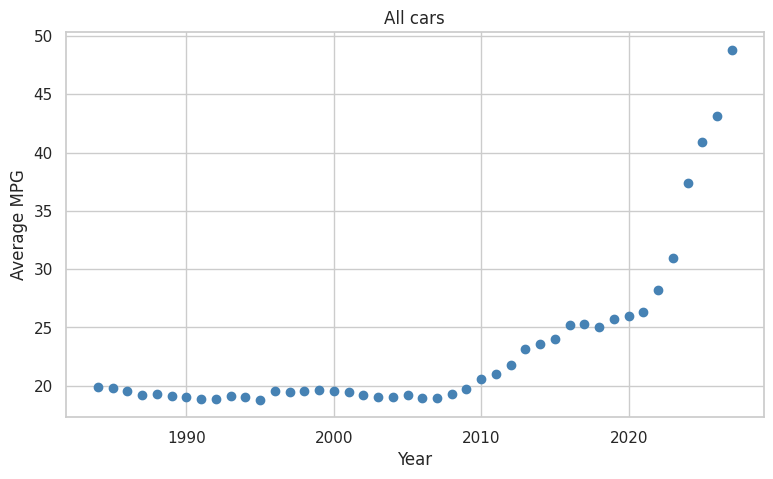

In [11]:
fig, ax = plt.subplots()
ax.scatter(averaged["year"], averaged["comb08_mean"], color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Average MPG")
ax.set_title("All cars")
plt.show()


The plot rises sharply after ~2010. The book's hypothesis: this could be an artifact of hybrids
(which post very high MPG) becoming more common, rather than genuine improvement of conventional engines.
Let's test that by filtering hybrids out.

In [12]:
criteria1 = vehicles["fuelType1"].isin(["Regular Gasoline", "Premium Gasoline", "Midgrade Gasoline"])
criteria2 = vehicles["fuelType2"].isnull()
criteria3 = vehicles["atvType"] != "Hybrid"

vehicles_non_hybrid = vehicles[criteria1 & criteria2 & criteria3].copy()
len(vehicles_non_hybrid)


43370

In [13]:
grouped = vehicles_non_hybrid.groupby("year")
averaged = grouped[["comb08"]].mean()
averaged


,comb08
year,
1984,19.121622
1985,19.394686
1986,19.320457
1987,19.164568
1988,19.367607
1989,19.141964
1990,19.031459
1991,18.838060
1992,18.861566


Even with hybrids removed, the upward trend since ~2008 survives — so it isn't purely a hybrid effect.

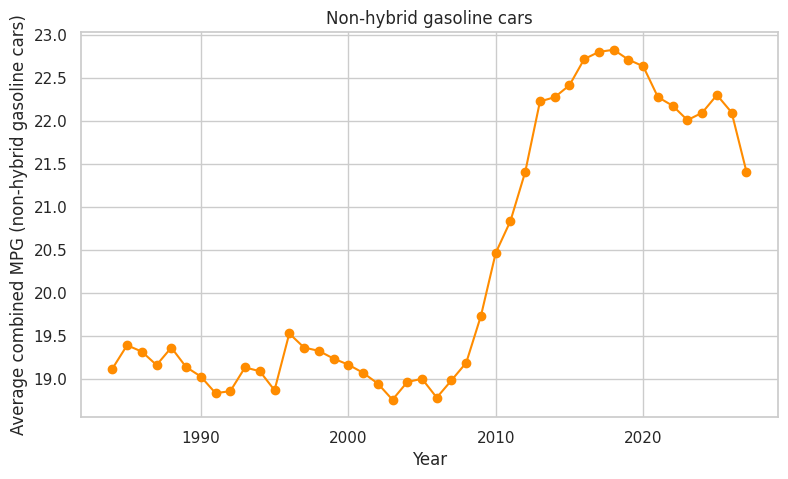

In [14]:
fig, ax = plt.subplots()
ax.plot(averaged.index, averaged["comb08"], marker="o", color="darkorange")
ax.set_xlabel("Year"); ax.set_ylabel("Average combined MPG (non-hybrid gasoline cars)")
ax.set_title("Non-hybrid gasoline cars")
plt.show()


### Does engine displacement explain the trend?

Recipe step: clean `displ` (drop `NaN`s, cast to float), then scatter against `comb08`.

In [15]:
vehicles_non_hybrid["displ"].unique()[:20]


array([2. , 4.9, 2.2, 5.2, 1.8, 1.6, 2.3, 2.8, 4. , 5. , 3.3, 3.1, 3.8,
       4.6, 3.4, 3. , 5.9, 2.5, 4.5, 6.8])

In [16]:
vehicles_non_hybrid = vehicles_non_hybrid[vehicles_non_hybrid["displ"].notnull()].copy()
vehicles_non_hybrid["displ"] = vehicles_non_hybrid["displ"].astype(float)

vehicles_non_hybrid = vehicles_non_hybrid[vehicles_non_hybrid["comb08"].notnull()].copy()
vehicles_non_hybrid["comb08"] = vehicles_non_hybrid["comb08"].astype(float)
len(vehicles_non_hybrid)


43368

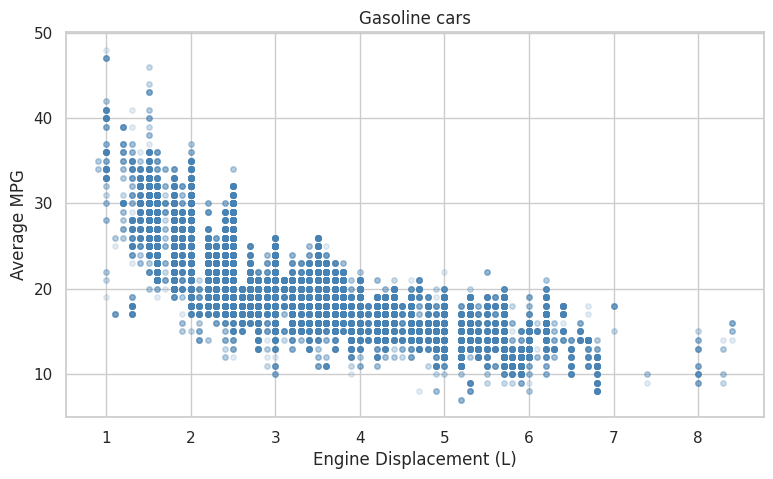

In [17]:
fig, ax = plt.subplots()
ax.scatter(vehicles_non_hybrid["displ"], vehicles_non_hybrid["comb08"],
           alpha=0.15, s=15, color="steelblue")
ax.set_xlabel("Engine Displacement (L)")
ax.set_ylabel("Average MPG")
ax.set_title("Gasoline cars")
plt.show()


Clear negative relationship: bigger engines -> lower MPG, as expected from basic thermodynamics/physics of combustion (more displaced volume per cycle = more fuel burned per stroke, all else equal).

In [18]:
avg_grouped_by_year = (
    vehicles_non_hybrid.groupby("year")[["displ", "comb08"]]
    .mean()
    .reset_index()
)
avg_grouped_by_year.head()


,year,displ,comb08
0,1984,3.068449,19.121622
1,1985,3.075990,19.389358
2,1986,3.126514,19.320457
3,1987,3.096474,19.164568
4,1988,3.113558,19.367607


### Reshaping wide -> long with `pd.melt` for a faceted comparison

The book uses `ggplot`'s `facet_wrap`; we replicate the same idea with matplotlib subplots after
melting the data into long format (one row per year per variable).

In [19]:
melted = avg_grouped_by_year.melt(id_vars="year", value_vars=["comb08", "displ"],
                                   var_name="variable", value_name="value")
melted.head()


,year,variable,value
0,1984,comb08,19.121622
1,1985,comb08,19.389358
2,1986,comb08,19.320457
3,1987,comb08,19.164568
4,1988,comb08,19.367607


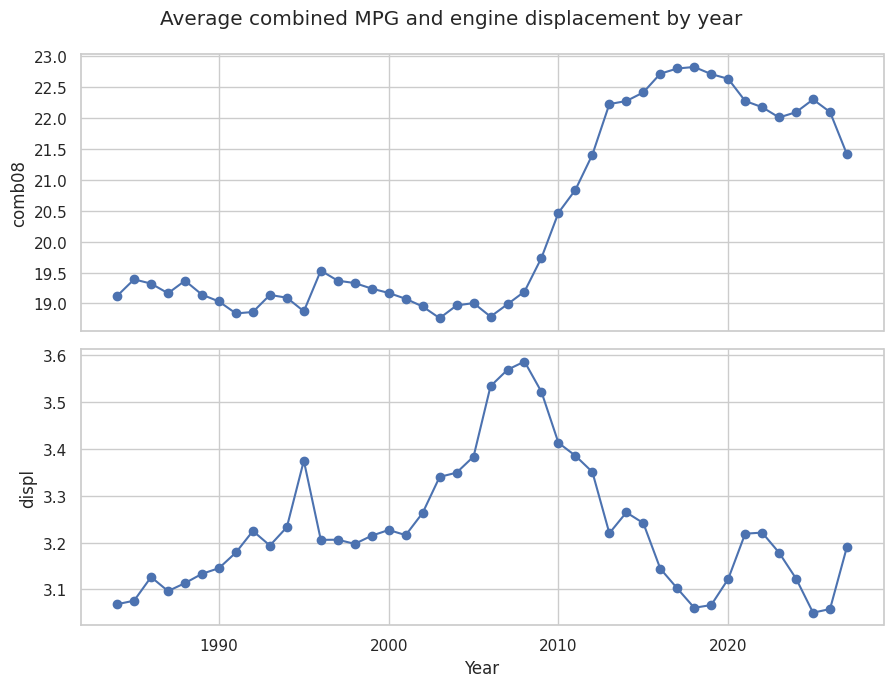

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, var in zip(axes, ["comb08", "displ"]):
    sub = melted[melted["variable"] == var]
    ax.plot(sub["year"], sub["value"], marker="o")
    ax.set_ylabel(var)
axes[-1].set_xlabel("Year")
fig.suptitle("Average combined MPG and engine displacement by year")
plt.tight_layout()
plt.show()


**Reading the two panels together:** average displacement (`displ`) is essentially flat across the
whole period, while average MPG (`comb08`) rises sharply after ~2008. That combination tells us the MPG
gain is **not** explained by cars simply getting smaller engines — something else (turbocharging,
direct injection, better transmissions, lighter materials, stricter CAFE standards) is driving the
efficiency gain. This is exactly the kind of "candidate explanation ruled out" finding that
split-apply-combine + visualization is good at producing quickly.

## Part 3 — Investigating makes and models

Recipe reference: *Investigating the makes and models of automobiles with Python*.

In [21]:
vehicles_non_hybrid["cylinders"].unique()


array([ 4., 12.,  8.,  6.,  5., 10.,  2.,  3., 16., nan])

In [22]:
vehicles_non_hybrid_4 = vehicles_non_hybrid[vehicles_non_hybrid["cylinders"] == 4.0].copy()
len(vehicles_non_hybrid_4)


17537

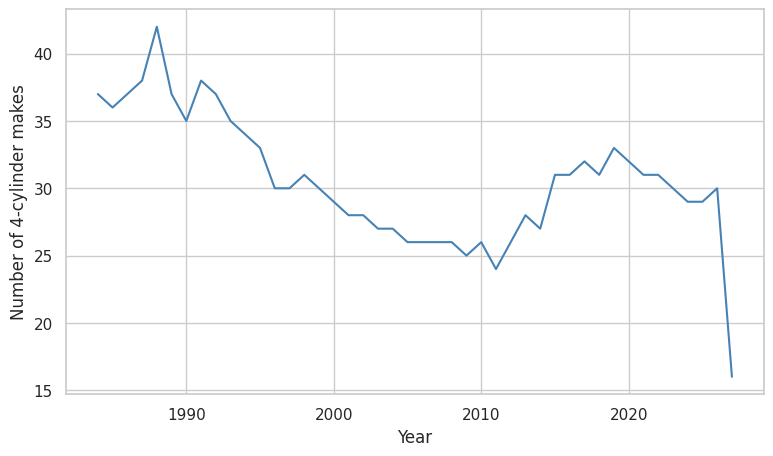

In [23]:
makes_per_year = vehicles_non_hybrid_4.groupby("year")["make"].nunique()

fig, ax = plt.subplots()
ax.plot(makes_per_year.index, makes_per_year.values, color="steelblue")
ax.set_xlabel("Year"); ax.set_ylabel("Number of 4-cylinder makes")
plt.show()


### Which makes offered a 4-cylinder car in *every* model year?

The book does this with a manual `for` loop over grouped years; we replicate it, then show the
one-line, fully-vectorized `pandas` equivalent the book itself points out afterwards.

In [24]:
grouped_by_year_4cyl = vehicles_non_hybrid_4.groupby("year")

unique_makes_per_year = [set(group["make"].unique()) for _, group in grouped_by_year_4cyl]
from functools import reduce
unique_makes = reduce(set.intersection, unique_makes_per_year)
sorted(unique_makes)


['Chevrolet', 'Honda', 'Jeep', 'Mitsubishi', 'Subaru', 'Toyota', 'Volkswagen']

In [25]:
len(unique_makes)


7

In [26]:
# Vectorized equivalent (no explicit for-loop needed)
df_common_makes = vehicles_non_hybrid_4[vehicles_non_hybrid_4["make"].isin(unique_makes)].copy()
len(df_common_makes)


6183

In [27]:
df_common_makes_grouped = (
    df_common_makes.groupby(["year", "make"])["comb08"]
    .mean()
    .reset_index()
)
df_common_makes_grouped.head()


,year,make,comb08
0,1984,Chevrolet,22.843750
1,1984,Honda,28.083333
2,1984,Jeep,20.250000
3,1984,Mitsubishi,21.070175
4,1984,Subaru,23.029412


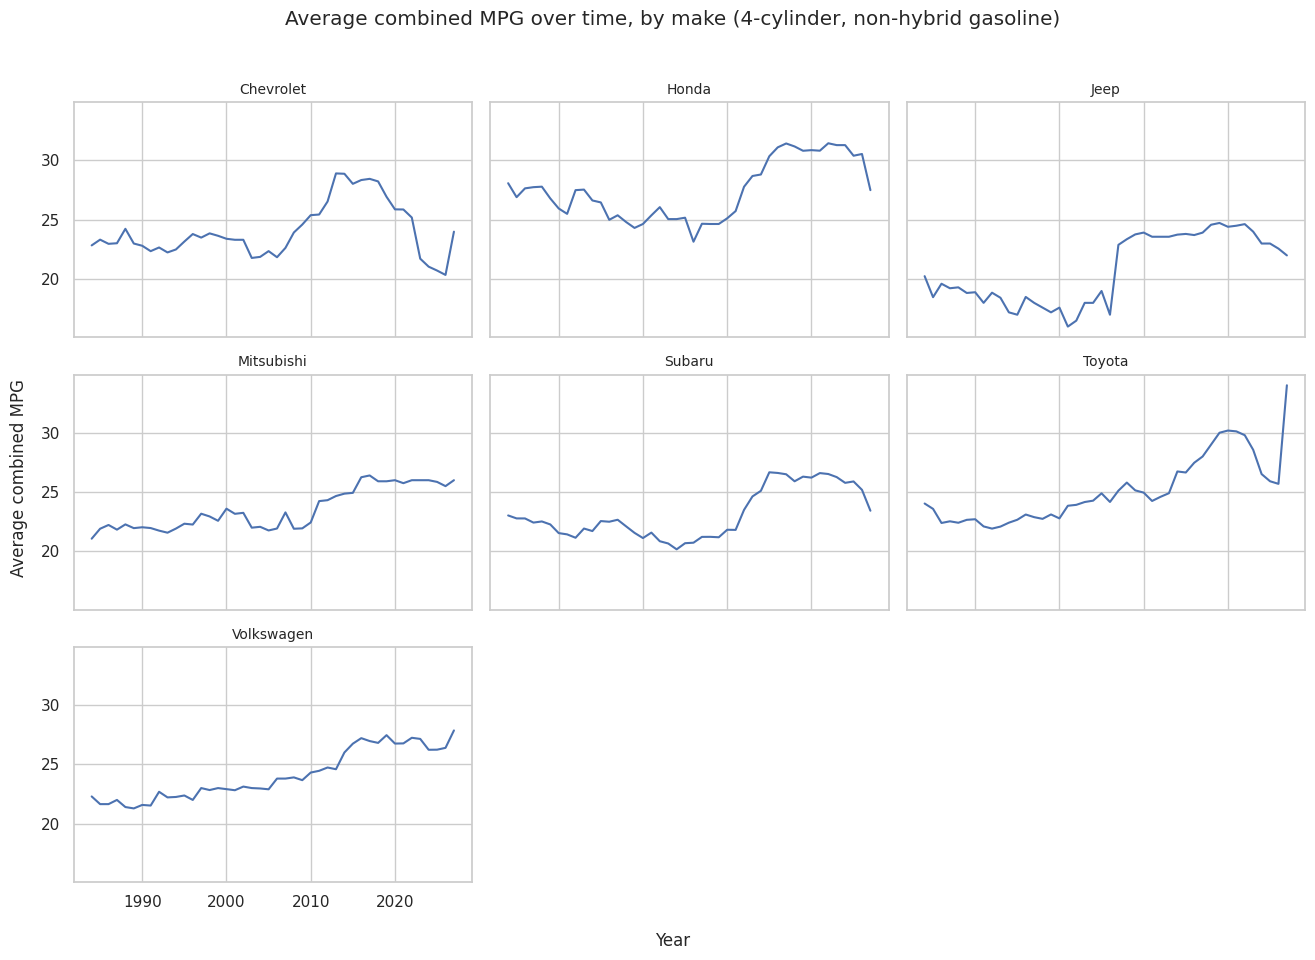

In [28]:
makes_sorted = sorted(df_common_makes_grouped["make"].unique())
n_makes = len(makes_sorted)
ncols = 3
nrows = -(-n_makes // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, mk in zip(axes, makes_sorted):
    sub = df_common_makes_grouped[df_common_makes_grouped["make"] == mk]
    ax.plot(sub["year"], sub["comb08"])
    ax.set_title(mk, fontsize=10)

for ax in axes[n_makes:]:
    ax.axis("off")

fig.suptitle("Average combined MPG over time, by make (4-cylinder, non-hybrid gasoline)", y=1.02)
fig.text(0.5, -0.02, "Year", ha="center")
fig.text(-0.01, 0.5, "Average combined MPG", va="center", rotation="vertical")
plt.tight_layout()
plt.show()


Every manufacturer that has stayed in the 4-cylinder segment continuously shows the same broad shape: flat-to-slightly-declining through the 1990s/2000s, then a marked climb after roughly 2008-2010 — consistent with the fleet-wide pattern we found in Part 2, and with the CAFE standard tightening that took effect over that period.

## Part 4 — Extensions beyond the book

These go past what the original chapter covers, and are good material for the "Challenge Exercises" in
the skeleton notebook.

### 4.1 — Correlation heatmap of efficiency-related numeric variables

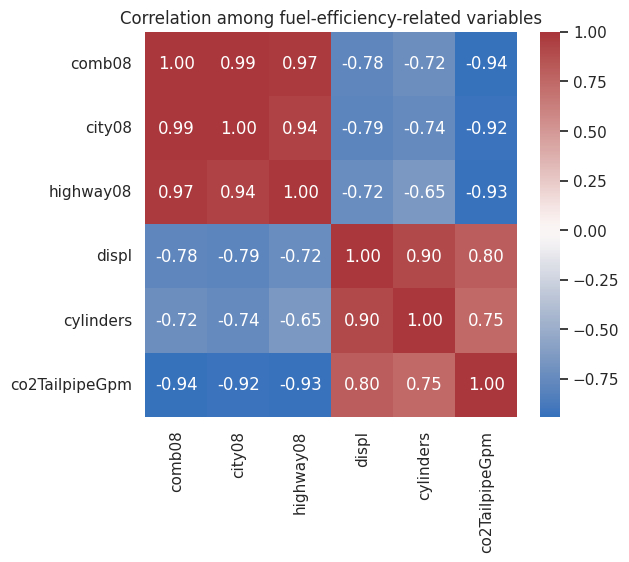

In [29]:
numeric_cols = ["comb08", "city08", "highway08", "displ", "cylinders", "co2TailpipeGpm"]
corr = vehicles_non_hybrid[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation among fuel-efficiency-related variables")
plt.show()


### 4.2 — Distribution of MPG by drivetrain

/tmp/ipykernel_516/110253282.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


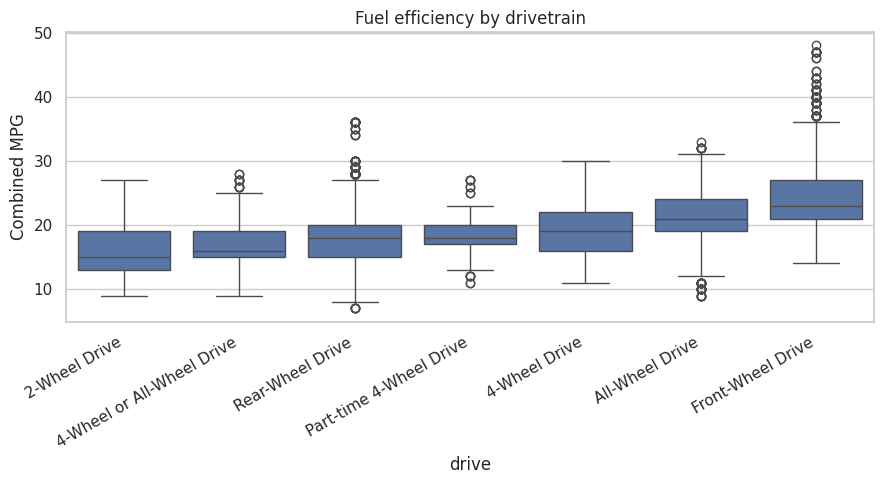

In [30]:
drive_order = (
    vehicles_non_hybrid.groupby("drive")["comb08"].median().sort_values().index
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=vehicles_non_hybrid, x="drive", y="comb08", order=drive_order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_ylabel("Combined MPG")
ax.set_title("Fuel efficiency by drivetrain")
plt.tight_layout()
plt.show()


### 4.3 — Electric vs. gasoline (why the modern dataset needs its own handling)

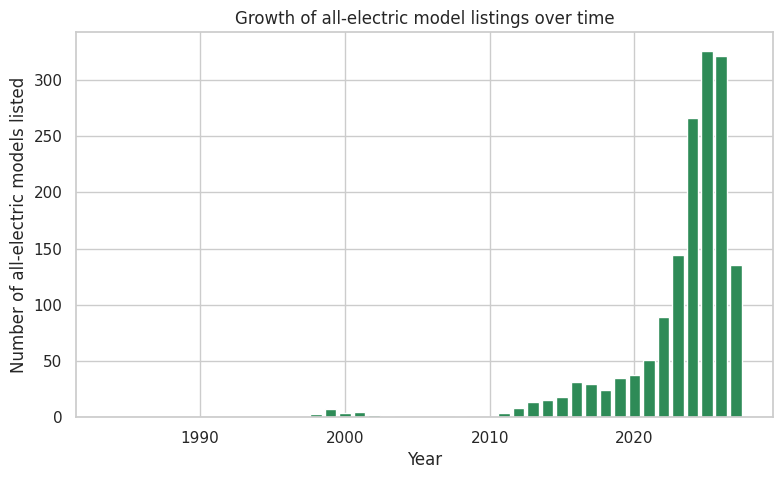

In [31]:
fuel_counts_by_year = (
    vehicles.assign(is_electric=vehicles["fuelType1"].eq("Electricity"))
    .groupby("year")["is_electric"].sum()
)
fig, ax = plt.subplots()
ax.bar(fuel_counts_by_year.index, fuel_counts_by_year.values, color="seagreen")
ax.set_xlabel("Year"); ax.set_ylabel("Number of all-electric models listed")
ax.set_title("Growth of all-electric model listings over time")
plt.show()


Electric vehicles report `comb08` in **MPGe** (MPG-equivalent), a different physical quantity than
gasoline MPG. Mixing them into the same average (as `vehicles["comb08"].mean()` would do if you forgot
to filter) silently produces a nonsensical number. This is a good, concrete illustration of why
**understanding what a column actually measures** is as important as knowing how to call `.mean()` on it.

## Recap

| Question | Finding |
|---|---|
| Has average fuel economy improved since the 1980s? | Yes, and the rise sharply accelerates post-2008, even after removing hybrids. |
| Is the improvement just due to smaller engines? | No — average displacement is roughly flat while MPG climbs, so something else (technology, regulation) is driving it. |
| Do all long-running manufacturers show the same pattern? | Yes, the dozen makes present in every year of the study all show flat-then-rising MPG in the same period. |
| Does drivetrain matter? | Yes — front-wheel-drive vehicles tend to be more efficient than 4WD/AWD, largely because of vehicle class/weight differences, not drivetrain physics alone. |
